# **Install and import what is necessary to carry out the training**

In [ ]:
# Importing libraries and mounting the drive where the dataset is stored
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style(style = 'whitegrid')
%matplotlib inline
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install datasets
!pip install transformers==4.28.0  # Later versions are having problems with TrainingArguments.
!pip install evaluate
!pip install wandb
import tensorflow as tf
import gc, torch
from datasets import load_dataset
import evaluate
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments, EarlyStoppingCallback, DataCollatorWithPadding, TextClassificationPipeline, logging
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 486.2/486.2 kB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.5/212.5 kB 28.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 18.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 44.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.8/236.8 kB 28.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.5/114.5 kB 14.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 31.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.6/149.6 kB 18.9 MB/s eta 0:00:00
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 68.4 MB/s eta 0:00

# **Define common training functions to all models**

In [ ]:
def load_corpus_Salud(drop, n_labels, task):
  dataset = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFG/CorpusSalud.csv", sep=";")[["Texto", "Polaridad", "Emociones"]]
  dataset.drop(dataset.tail(drop).index, inplace = True)
  dataset.columns = ["text", "label", "emotion"]
  if(task=="sentiment"):
    if(n_labels==2):
      dataset = dataset.loc[dataset["label"] != "Indeterminado"]
      dataset['label'] = [0 if item=="Negativa" else 1 for item in dataset['label']]
    else:
      dataset['label'] = [0 if item=="Negativa" else 1 if item=="Indeterminado" else 2 for item in dataset['label']]
    return dataset[["text", "label"]]
  else:
    dataset['label'] = [0 if item=="Amor/Admiración" else 1 if item=="Gratitud" else 2 if item=='Tristeza/Pena' else 3 if item=='Enfado/Desprecio/Burla' else 4 if item=="Comprensión/Empatía/Identificación"
                          else 5 for item in dataset['emotion']]
    return dataset[["text", "label"]]    # Mandatory for headers to be ["text", "label"] for trainer


def compute_metrics(eval_pred):
    metric1 = evaluate.load("accuracy")
    metric2 = evaluate.load("precision")
    metric3 = evaluate.load("recall")
    metric4 = evaluate.load("f1")
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = metric1.compute(predictions=predictions, references=labels)["accuracy"]
    precision = metric2.compute(predictions=predictions, references=labels, average="weighted")["precision"]
    recall = metric3.compute(predictions=predictions, references=labels, average="weighted")["recall"]
    f1 = metric4.compute(predictions=predictions, references=labels, average="weighted")["f1"]
    return {"accuracy":accuracy, "precision":precision, "recall":recall, "f1":f1}


def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True)

def garbage_collector():
  torch.cuda.empty_cache()
  gc.collect()
  !nvidia-smi

earlyStop=EarlyStoppingCallback()


#Prediction function
#name = "roberta", "robertuito" if task=="sentiment". "daveni", "robertuito" if task=="emotion"
#task = "sentiment", "emotion"
#data = string data or list of strings to predict from

#return = prediction or list of predictions
def predict(name, task, data):
  if(task=="emotion"):
    num_labels=6
    id2label = {0: "Amor/Admiración", 1: "Gratitud", 2: "Tristeza/Pena",
                3:"Enfado/Desprecio/Burla", 4:"Comprensión/Empatía/Identificación", 5:"Indiferente"}
    label2id = {"Amor/Admiración":0, "Gratitud":1, "Tristeza/Pena":2,
                "Enfado/Desprecio/Burla":3, "Comprensión/Empatía/Identificación":4, "Indiferente":5}
  else:
    num_labels=3
    id2label = {0: "NEG", 1: "NEU", 2: "POS"}
    label2id = {"NEG": 0, "NEU": 1, "POS": 2}

  logging.set_verbosity_error()
  model_path = "./drive/MyDrive/Colab Notebooks/TFG/Salud/model_"+name+"_"+task
  tok_path = "./drive/MyDrive/Colab Notebooks/TFG/Salud/tok_"+name+"_"+task
  model = AutoModelForSequenceClassification.from_pretrained(model_path, num_labels=num_labels,
                              label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
  tokenizer = AutoTokenizer.from_pretrained(tok_path)
  pipe = TextClassificationPipeline(model=model, tokenizer=tokenizer, top_k=1, device=0)
  logging.set_verbosity_warning()
  return([i[0]["label"] for i in pipe(data)])


# **Analysis of Emotions**

                                               Texto        Emociones
0  ¡Animo guapa! Aquí tienes a tu familia virtual...  Amor/Admiración
1  ¡Nos alegra tenerte nuevamente por aquí!.Te ec...  Amor/Admiración
2  @dulceida Puedes con todo, pero no todo al mis...  Amor/Admiración
3  @mpombor  mucho ánimo y estamos contigo muchos...  Amor/Admiración
4  @tamara_gorro GUAPA,no te conozco pero me tran...  Amor/Admiración


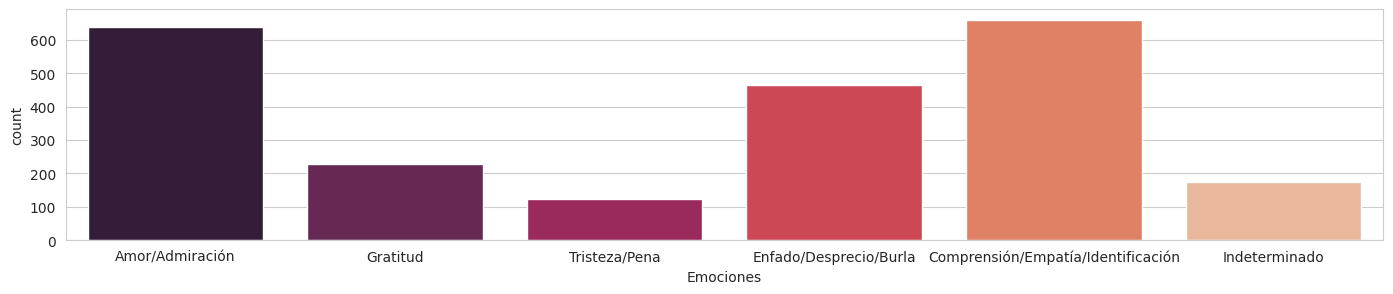

In [ ]:
dataset = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/TFG/CorpusSalud.csv", sep=";")[["Texto", "Emociones"]]

print(dataset.head())

plt.figure(figsize=(17, 3))
sns.countplot(x = 'Emociones', data = dataset, palette = 'rocket',
              order=['Amor/Admiración', 'Gratitud', 'Tristeza/Pena', 'Enfado/Desprecio/Burla', 'Comprensión/Empatía/Identificación', 'Indeterminado']);

In [ ]:
print(len(dataset[dataset["Emociones"]=='Amor/Admiración']))
print(len(dataset[dataset["Emociones"]=='Gratitud']))
print(len(dataset[dataset["Emociones"]=='Tristeza/Pena']))
print(len(dataset[dataset["Emociones"]=='Enfado/Desprecio/Burla']))
print(len(dataset[dataset["Emociones"]=='Comprensión/Empatía/Identificación']))
print(len(dataset[dataset["Emociones"]=='Indeterminado']))

640
227
122
466
659
173


## **Daveni Model**

##### **Initial test**

In [ ]:
dataset = load_corpus_Salud(0, n_labels=6, task="emotion")
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}


tokenizer = AutoTokenizer.from_pretrained("daveni/twitter-xlm-roberta-emotion-es")
model = AutoModelForSequenceClassification.from_pretrained("daveni/twitter-xlm-roberta-emotion-es", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
data_collator = DataCollatorWithPadding(tokenizer)

train, test = train_test_split(dataset, stratify=dataset["label"])

train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

training_args = TrainingArguments(num_train_epochs = 10, output_dir="best-sweep-12", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[earlyStop]
  )
trainer.train()
pred=trainer.predict(tokenized_datasets["test"])
logits=pred.predictions
prob=tf.nn.softmax(logits)
res=np.argmax(prob, axis=1) # predictions

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-205d76d52013799f/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1. Subsequent calls will reuse this data.


...

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


<IPython.core.display.Javascript object>

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.571952,0.837413,0.848639,0.837413,0.832794
2,No log,0.651366,0.844406,0.849343,0.844406,0.839322
3,0.535800,0.868442,0.832168,0.840024,0.832168,0.831833


In [ ]:
print(classification_report(tokenized_datasets["test"]["label"], res, digits=4))

              precision    recall  f1-score   support

           0     0.9030    0.9313    0.9169       160
           1     0.7727    0.8947    0.8293        57
           2     0.6757    0.8333    0.7463        30
           3     0.8547    0.8547    0.8547       117
           4     0.8383    0.8485    0.8434       165
           5     0.9000    0.4186    0.5714        43

    accuracy                         0.8444       572
   macro avg     0.8241    0.7969    0.7937       572
weighted avg     0.8493    0.8444    0.8393       572



##### **Tunning process**

In [ ]:
import wandb
wandb.login()

<IPython.core.display.Javascript object>

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


True

In [ ]:
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}

tokenizer = AutoTokenizer.from_pretrained("daveni/twitter-xlm-roberta-emotion-es")
model = AutoModelForSequenceClassification.from_pretrained("daveni/twitter-xlm-roberta-emotion-es", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
data_collator = DataCollatorWithPadding(tokenizer)


dataset = load_corpus_Salud(drop=0, n_labels = 6, task="emotion") # with emotion the number of labels does not matter
train, test = train_test_split(dataset, stratify=dataset["label"])
train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-9a657b5bd3431352/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1. Subsequent calls will reuse this data.


  0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/1714 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/572 [00:00<?, ? examples/s]

In [ ]:
config = {
          "wandb":{
            "project": "wandb-daveni-emotion",
            "api_key": "8bbff3610b2cf78be4379caaff269965fbae9000"
        }
}


def wandb_hp_space(trial):
    return {
        "method": "random",
        "metric": {"name": "accuracy", "goal": "maximize"},
        "parameters": {
            "learning_rate": {"distribution": "uniform", "min": 1e-6, "max": 1e-4},
            "per_device_train_batch_size": {"values": [2, 4, 8, 16, 32, 64, 128]},
            "per_device_eval_batch_size": {"values": [2, 4, 8, 16, 32, 64, 128]},
            "num_train_epochs" : {"distribution": "int_uniform", "min": 5, "max": 15}
        },
    }

def model_init(trial):
    return AutoModelForSequenceClassification.from_pretrained(
        "daveni/twitter-xlm-roberta-emotion-es", ignore_mismatched_sizes=True,
        config=config, num_labels=6, label2id = label2id, id2label=id2label
    )


training_args = TrainingArguments(report_to="wandb", output_dir="wandb-daveni-emotion", overwrite_output_dir=True,
       evaluation_strategy="epoch", per_device_train_batch_size = 128, per_device_eval_batch_size=128, num_train_epochs = 10,
                                    fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") # necessary to earlyStop

trainer = Trainer(
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    model_init=model_init,
    data_collator=data_collator,
    callbacks=[earlyStop]
)

best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="wandb",
    hp_space=wandb_hp_space,
    n_trials=30
)


wandb.finish()

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Create sweep with ID: 935suuc8
Sweep URL: https://wandb.ai/tfg-transformers/uncategorized/sweeps/935suuc8


wandb: Agent Starting Run: 27rklv3p with config:
wandb: 	learning_rate: 5.339495469662278e-05
wandb: 	num_train_epochs: 6
wandb: 	per_device_eval_batch_size: 16
wandb: 	per_device_train_batch_size: 2
wandb: Currently logged in as: javier-estase (tfg-transformers). Use `wandb login --relogin` to force relogin


Trying to set _wandb in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set assignments in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set metric in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implemen

wandb: WARNING Ignored wandb.init() arg project when running a sweep.


...

Run 3apmk0aj errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')
wandb: ERROR Run 3apmk0aj errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')
wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: g144u4nf with config:
wandb: 	learning_rate: 9.908066695448617e-05
wandb: 	num_train_epochs: 8
wandb: 	per_device_eval_batch_size: 2
wandb: 	per_device_

Trying to set _wandb in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set assignments in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set metric in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Run g144u4nf errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')
wandb: ERROR Run g144u4nf errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')
wandb: Sweep Agent: Waiting for job.
wandb: Job received.
wandb: Agent Starting Run: gn9dx42v with config:
wandb: 	learning_rate: 4.3809788256894274e-05
wandb: 	num_train_epochs: 6
wandb: 	per_device_eval_batch_size: 32
wandb: 	per_devic

Trying to set _wandb in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set assignments in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Trying to set metric in the hyperparameter search but there is no corresponding field in `TrainingArguments`.
Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Run gn9dx42v errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')
wandb: ERROR Run gn9dx42v errored: OutOfMemoryError('CUDA out of memory. Tried to allocate 734.00 MiB (GPU 0; 14.75 GiB total capacity; 13.31 GiB already allocated; 46.81 MiB free; 13.92 GiB reserved in total by PyTorch) If reserved memory is >> allocated memory try setting max_split_size_mb to avoid fragmentation.  See documentation for Memory Management and PYTORCH_CUDA_ALLOC_CONF')


##### **KFold process**

In [ ]:
dataset = load_corpus_Salud(0, n_labels=6, task="emotion")
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}
splits=10
JOY = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
FEAR = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
SAD = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
ANG = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
SUR = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
OTHER = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])

macro = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
weighted = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
acc= pd.DataFrame(columns=["accuracy"])

i=0
kf = StratifiedKFold(n_splits = splits, random_state=10, shuffle=True)
for train, test in kf.split(X=dataset["text"], y=dataset["label"]):
  print("\n\n******************BUCLE", i, "**************************\n\n")

  tokenizer = AutoTokenizer.from_pretrained("daveni/twitter-xlm-roberta-emotion-es")
  model = AutoModelForSequenceClassification.from_pretrained("daveni/twitter-xlm-roberta-emotion-es", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
  data_collator = DataCollatorWithPadding(tokenizer)
  #print(dataset.iloc[train]["label"].unique())
  #print(dataset.iloc[test]["label"].unique())
  dataset.iloc[train].to_csv("corpus_train.csv", index=False)
  dataset.iloc[test].to_csv("corpus_test.csv", index=False)
  train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
  tokenized_datasets = train_test.map(tokenize_function, batched=True)

  training_args = TrainingArguments(learning_rate=0.00001409, num_train_epochs=12, per_device_train_batch_size = 8, per_device_eval_batch_size=2,
                                  output_dir="best-sweep-2", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

  trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[earlyStop]
  )
  trainer.train()
  pred=trainer.predict(tokenized_datasets["test"])
  logits=pred.predictions
  prob=tf.nn.softmax(logits)
  res=np.argmax(prob, axis=1) # predictions

  report = classification_report(tokenized_datasets["test"]["label"], res, output_dict=True)
  JOY.loc[i] = report["0"]
  FEAR.loc[i] = report["1"]
  SAD.loc[i] = report["2"]
  ANG.loc[i] = report["3"]
  SUR.loc[i] = report["4"]
  OTHER.loc[i] = report["5"]
  macro.loc[i] = report["macro avg"]
  weighted.loc[i] = report["weighted avg"]
  acc.loc[i] = report["accuracy"]
  i+=1








******************BUCLE 0 **************************




Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

...

Map:   0%|          | 0/2058 [00:00<?, ? examples/s]

Asking to pad to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no padding.
Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


Map:   0%|          | 0/228 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.510780,0.842105,0.836132,0.842105,0.832095
2,0.678700,0.462569,0.850877,0.851945,0.850877,0.849340
3,0.678700,0.587193,0.868421,0.872782,0.868421,0.868111
4,0.166700,0.748895,0.855263,0.855968,0.855263,0.852801


In [ ]:
JOY

,precision,recall,f1-score,support
0,0.845070,0.937500,0.888889,64
1,0.880597,0.921875,0.900763,64
2,0.847222,0.953125,0.897059,64
3,0.966667,0.906250,0.935484,64
4,0.903226,0.875000,0.888889,64
5,0.882353,0.937500,0.909091,64
6,0.953125,0.953125,0.953125,64
7,0.937500,0.937500,0.937500,64
8,0.935484,0.906250,0.920635,64
9,0.909091,0.937500,0.923077,64


In [ ]:
print(np.mean(JOY, axis=0))
# "Joy" translates in our dataset as the emotion "Love/Admiration"

precision     0.906033
recall        0.926562
f1-score      0.915451
support      64.000000
dtype: float64


In [ ]:
FEAR

,precision,recall,f1-score,support
0,0.956522,0.956522,0.956522,23
1,0.863636,0.826087,0.844444,23
2,0.950000,0.826087,0.883721,23
3,0.954545,0.913043,0.933333,23
4,1.000000,0.826087,0.904762,23
5,0.909091,0.869565,0.888889,23
6,0.916667,0.956522,0.936170,23
7,0.950000,0.863636,0.904762,22
8,0.950000,0.863636,0.904762,22
9,0.956522,1.000000,0.977778,22


In [ ]:
print(np.mean(FEAR, axis=0))
# "FEAR" translates in our dataset as the emotion "Gratitude"

precision     0.940698
recall        0.890119
f1-score      0.913514
support      22.700000
dtype: float64


In [ ]:
SAD

,precision,recall,f1-score,support
0,0.647059,0.916667,0.758621,12
1,0.818182,0.750000,0.782609,12
2,1.000000,0.833333,0.909091,12
3,0.900000,0.750000,0.818182,12
4,0.562500,0.750000,0.642857,12
5,0.875000,0.583333,0.700000,12
6,0.916667,0.916667,0.916667,12
7,0.833333,0.769231,0.800000,13
8,0.900000,0.750000,0.818182,12
9,0.687500,0.916667,0.785714,12


In [ ]:
print(np.mean(SAD, axis=0))
# "SAD" translates in our dataset as the emotion "Sadness"

precision     0.814024
recall        0.793590
f1-score      0.793192
support      12.100000
dtype: float64


In [ ]:
ANG

,precision,recall,f1-score,support
0,0.948718,0.787234,0.860465,47
1,0.867925,0.978723,0.920000,47
2,0.955556,0.914894,0.934783,47
3,0.750000,0.893617,0.815534,47
4,0.791667,0.826087,0.808511,46
5,0.777778,0.913043,0.840000,46
6,0.782609,0.782609,0.782609,46
7,0.851064,0.869565,0.860215,46
8,0.816327,0.851064,0.833333,47
9,0.923077,0.765957,0.837209,47


In [ ]:
print(np.mean(ANG, axis=0))
# "ANG" translates in our dataset as the emotion "Anger/Contempt/Mockery"

precision     0.846472
recall        0.858279
f1-score      0.849266
support      46.600000
dtype: float64


In [ ]:
SUR

,precision,recall,f1-score,support
0,0.929825,0.803030,0.861789,66
1,0.903226,0.848485,0.875000,66
2,0.909091,0.909091,0.909091,66
3,0.772152,0.938462,0.847222,65
4,0.730769,0.863636,0.791667,66
5,0.777778,0.848485,0.811594,66
6,0.869565,0.909091,0.888889,66
7,0.849315,0.939394,0.892086,66
8,0.847222,0.924242,0.884058,66
9,0.865672,0.878788,0.872180,66


In [ ]:
print(np.mean(SUR, axis=0))
# "SUR" translates in our dataset as the emotion "Comprehension/Empathy/Identification"

precision     0.845461
recall        0.886270
f1-score      0.863358
support      65.900000
dtype: float64


In [ ]:
OTHER

,precision,recall,f1-score,support
0,0.636364,0.823529,0.717949,17
1,0.857143,0.705882,0.774194,17
2,0.875000,0.823529,0.848485,17
3,0.000000,0.000000,0.000000,18
4,0.833333,0.277778,0.416667,18
5,1.000000,0.277778,0.434783,18
6,0.615385,0.470588,0.533333,17
7,0.750000,0.529412,0.620690,17
8,0.800000,0.705882,0.750000,17
9,0.647059,0.647059,0.647059,17


In [ ]:
print(np.mean(OTHER, axis=0))
# "OTHER" translates in our dataset as the emotion "Neutral"

precision     0.701428
recall        0.526144
f1-score      0.574316
support      17.300000
dtype: float64


In [ ]:
macro

,precision,recall,f1-score,support
0,0.827260,0.870747,0.840706,229
1,0.865118,0.838509,0.849502,229
2,0.922811,0.876677,0.897038,229
3,0.723894,0.733562,0.724959,229
4,0.803583,0.736431,0.742225,229
5,0.870333,0.738284,0.764059,229
6,0.842336,0.831434,0.835132,228
7,0.861869,0.818123,0.835875,228
8,0.874839,0.833512,0.851828,228
9,0.831487,0.857662,0.840503,228


In [ ]:
print(np.mean(macro, axis=0))
# macro metric

precision      0.842353
recall         0.813494
f1-score       0.818183
support      228.600000
dtype: float64


In [ ]:
weighted

,precision,recall,f1-score,support
0,0.876094,0.860262,0.862521,229
1,0.877803,0.877729,0.876042,229
2,0.907678,0.903930,0.903954,229
3,0.786293,0.834061,0.805919,229
4,0.817484,0.803493,0.796306,229
5,0.842755,0.829694,0.816845,229
6,0.863755,0.868421,0.865198,228
7,0.875820,0.877193,0.874141,228
8,0.874803,0.872807,0.872404,228
9,0.872782,0.868421,0.868111,228


In [ ]:
print(np.mean(weighted, axis=0))
# weighted metric

precision      0.859527
recall         0.859601
f1-score       0.854144
support      228.600000
dtype: float64


In [ ]:
acc

,accuracy
0,0.860262
1,0.877729
2,0.903930
3,0.834061
4,0.803493
5,0.829694
6,0.868421
7,0.877193
8,0.872807
9,0.868421


In [ ]:
print(np.mean(acc, axis=0))
# accuracy metric (global metric)

accuracy    0.859601
dtype: float64


## **ROBERTUITO Model**

##### Initial test

In [ ]:
dataset = load_corpus_Salud(0, n_labels=6, task="emotion")
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}


tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-emotion-analysis")
model = AutoModelForSequenceClassification.from_pretrained("pysentimiento/robertuito-emotion-analysis", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
data_collator = DataCollatorWithPadding(tokenizer)

train, test = train_test_split(dataset, stratify=dataset["label"])

train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

training_args = TrainingArguments(output_dir="try", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[earlyStop]
  )
trainer.train()
pred=trainer.predict(tokenized_datasets["test"])
logits=pred.predictions
prob=tf.nn.softmax(logits)
res=np.argmax(prob, axis=1) # predictions
print(classification_report(tokenized_datasets["test"]["label"], res, digits=4))

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-emotion-analysis and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-0627edb342732d76/0.0.0/eea64c71ca8b46dd3f537ed218fc9bf495d5707789152eb2764f5c78fa66d59d. Subsequent calls will reuse this data.


...

 ··········


wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.389796,0.875874,0.879792,0.875874,0.876532
2,No log,0.427955,0.891608,0.891008,0.891608,0.890274
3,0.353900,0.472609,0.893357,0.893592,0.893357,0.892310


              precision    recall  f1-score   support

           0     0.9277    0.9625    0.9448       160
           1     0.8929    0.8772    0.8850        57
           2     0.7714    0.9000    0.8308        30
           3     0.9455    0.8889    0.9163       117
           4     0.8706    0.8970    0.8836       165
           5     0.8000    0.6512    0.7179        43

    accuracy                         0.8934       572
   macro avg     0.8680    0.8628    0.8631       572
weighted avg     0.8936    0.8934    0.8923       572



**Tunning process of the model**

In [ ]:
import wandb
wandb.login()

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

In [ ]:
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}

tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-emotion-analysis")
model = AutoModelForSequenceClassification.from_pretrained("pysentimiento/robertuito-emotion-analysis", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
data_collator = DataCollatorWithPadding(tokenizer)


dataset = load_corpus_Salud(drop=0, n_labels = 6, task="emotion") #con emotion el nº de labels no importa
train, test = train_test_split(dataset, stratify=dataset["label"])
train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-emotion-analysis and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-c61c7032e9fb6ec2/0.0.0/eea64c71ca8b46dd3f537ed218fc9bf495d5707789152eb2764f5c78fa66d59d. Subsequent calls will reuse this data.


  0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/1714 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

In [ ]:
config = {
          "wandb":{
            "project": "wandb-robertuito-emotion",
            "api_key": "8bbff3610b2cf78be4379caaff269965fbae9000"
        }
}


def wandb_hp_space(trial):
    return {
        "method": "random",
        "metric": {"name": "accuracy", "goal": "maximize"},
        "parameters": {
            "learning_rate": {"distribution": "uniform", "min": 1e-6, "max": 1e-4},
            "per_device_train_batch_size": {"values": [2, 4, 8, 16, 32, 64]},
            "per_device_eval_batch_size": {"values": [2, 4, 8, 16, 32, 64]},
            "num_train_epochs" : {"distribution": "int_uniform", "min": 5, "max": 15}
        },
    }

def model_init(trial):
    return AutoModelForSequenceClassification.from_pretrained(
        "pysentimiento/robertuito-emotion-analysis", ignore_mismatched_sizes=True,
        config=config, num_labels=6, label2id = label2id, id2label=id2label
    )


training_args = TrainingArguments(report_to="wandb" , output_dir="wandb-robertuito-emotion", overwrite_output_dir=True,
       evaluation_strategy="epoch", per_device_train_batch_size = 128, per_device_eval_batch_size=128, num_train_epochs = 10,
                                    fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") # Necessary for earlyStop

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    model_init=model_init,
    data_collator=data_collator,
    callbacks=[earlyStop]
)

best_trial = trainer.hyperparameter_search(
    direction="maximize",
    backend="wandb",
    hp_space=wandb_hp_space,
    n_trials=15
)


wandb.finish()

##### **KFold process**

In [ ]:
dataset = load_corpus_Salud(0, n_labels=6, task="emotion")
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}


splits=10
JOY = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
FEAR = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
SAD = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
ANG = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
SUR = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
OTHER = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])


macro = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
weighted = pd.DataFrame(columns=["precision", "recall", "f1-score", "support"])
acc= pd.DataFrame(columns=["accuracy"])

i=0
kf = StratifiedKFold(n_splits = splits, random_state=10, shuffle=True)
for train, test in kf.split(X=dataset["text"], y=dataset["label"]):
  print("\n\n******************BUCLE", i, "**************************\n\n")

  tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-emotion-analysis")
  model = AutoModelForSequenceClassification.from_pretrained("pysentimiento/robertuito-emotion-analysis", num_labels=6, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True )
  data_collator = DataCollatorWithPadding(tokenizer)

  dataset.iloc[train].to_csv("corpus_train.csv", index=False)
  dataset.iloc[test].to_csv("corpus_test.csv", index=False)
  train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
  tokenized_datasets = train_test.map(tokenize_function, batched=True)

  training_args = TrainingArguments(learning_rate=0.00007557, num_train_epochs=6, per_device_train_batch_size = 16, per_device_eval_batch_size=16,
                                  output_dir="best-sweep-", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

  trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets["train"],
        eval_dataset=tokenized_datasets["test"],
        compute_metrics=compute_metrics,
        data_collator=data_collator,
        callbacks=[earlyStop]
  )
  trainer.train()
  pred=trainer.predict(tokenized_datasets["test"])
  logits=pred.predictions
  prob=tf.nn.softmax(logits)
  res=np.argmax(prob, axis=1) # predictions

  report = classification_report(tokenized_datasets["test"]["label"], res, output_dict=True)
  JOY.loc[i] = report["0"]
  FEAR.loc[i] = report["1"]
  SAD.loc[i] = report["2"]
  ANG.loc[i] = report["3"]
  SUR.loc[i] = report["4"]
  OTHER.loc[i] = report["5"]
  macro.loc[i] = report["macro avg"]
  weighted.loc[i] = report["weighted avg"]
  acc.loc[i] = report["accuracy"]
  i+=1








******************BUCLE 0 **************************




Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-emotion-analysis and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

...

  0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/2058 [00:00<?, ? examples/s]

Map:   0%|          | 0/228 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.333777,0.899123,0.899955,0.899123,0.895094
2,No log,0.385812,0.907895,0.904148,0.907895,0.903113
3,No log,0.498169,0.894737,0.892903,0.894737,0.891899


In [ ]:
JOY

,precision,recall,f1-score,support
0,0.968750,0.968750,0.968750,64
1,0.925373,0.968750,0.946565,64
2,0.840000,0.984375,0.906475,64
3,0.926471,0.984375,0.954545,64
4,0.952381,0.937500,0.944882,64
5,0.921875,0.921875,0.921875,64
6,0.968254,0.953125,0.960630,64
7,0.921875,0.921875,0.921875,64
8,0.897059,0.953125,0.924242,64
9,0.967742,0.937500,0.952381,64


In [ ]:
print(np.mean(JOY, axis=0))
# "Joy" translates in our dataset as the emotion "Love/Admiration"

precision     0.928978
recall        0.953125
f1-score      0.940222
support      64.000000
dtype: float64


In [ ]:
FEAR

,precision,recall,f1-score,support
0,0.916667,0.956522,0.936170,23
1,0.880000,0.956522,0.916667,23
2,0.904762,0.826087,0.863636,23
3,0.814815,0.956522,0.880000,23
4,1.000000,0.913043,0.954545,23
5,0.954545,0.913043,0.933333,23
6,0.884615,1.000000,0.938776,23
7,0.950000,0.863636,0.904762,22
8,0.826087,0.863636,0.844444,22
9,0.916667,1.000000,0.956522,22


In [ ]:
print(np.mean(FEAR, axis=0))
# "FEAR" translates in our dataset as the emotion "Gratitude"

precision     0.904816
recall        0.924901
f1-score      0.912886
support      22.700000
dtype: float64


In [ ]:
SAD

,precision,recall,f1-score,support
0,0.833333,0.833333,0.833333,12
1,0.800000,1.000000,0.888889,12
2,1.000000,0.750000,0.857143,12
3,0.800000,1.000000,0.888889,12
4,0.818182,0.750000,0.782609,12
5,0.846154,0.916667,0.880000,12
6,0.846154,0.916667,0.880000,12
7,0.800000,0.615385,0.695652,13
8,0.846154,0.916667,0.880000,12
9,0.909091,0.833333,0.869565,12


In [ ]:
print(np.mean(SAD, axis=0))
# "SAD" translates in our dataset as the emotion "Sadness"

precision     0.849907
recall        0.853205
f1-score      0.845608
support      12.100000
dtype: float64


In [ ]:
ANG

,precision,recall,f1-score,support
0,0.976190,0.872340,0.921348,47
1,0.955556,0.914894,0.934783,47
2,0.936170,0.936170,0.936170,47
3,0.956522,0.936170,0.946237,47
4,0.916667,0.956522,0.936170,46
5,0.895833,0.934783,0.914894,46
6,0.849057,0.978261,0.909091,46
7,0.877551,0.934783,0.905263,46
8,0.860000,0.914894,0.886598,47
9,0.895833,0.914894,0.905263,47


In [ ]:
print(np.mean(ANG, axis=0))
# "ANG" translates in our dataset as the emotion "Anger/Contempt/Mockery"

precision     0.911938
recall        0.929371
f1-score      0.919582
support      46.600000
dtype: float64


In [ ]:
SUR

,precision,recall,f1-score,support
0,0.885714,0.939394,0.911765,66
1,0.937500,0.909091,0.923077,66
2,0.868852,0.803030,0.834646,66
3,0.920635,0.892308,0.906250,65
4,0.910448,0.924242,0.917293,66
5,0.882353,0.909091,0.895522,66
6,0.888889,0.848485,0.868217,66
7,0.887097,0.833333,0.859375,66
8,0.932203,0.833333,0.880000,66
9,0.888889,0.969697,0.927536,66


In [ ]:
print(np.mean(SUR, axis=0))
# "SUR" translates in our dataset as the emotion "Comprehension/Empathy/Identification"

precision     0.900258
recall        0.886200
f1-score      0.892368
support      65.900000
dtype: float64


In [ ]:
OTHER


,precision,recall,f1-score,support
0,0.705882,0.705882,0.705882,17
1,0.846154,0.647059,0.733333,17
2,0.750000,0.705882,0.727273,17
3,0.900000,0.500000,0.642857,18
4,0.789474,0.833333,0.810811,18
5,0.857143,0.666667,0.750000,18
6,0.900000,0.529412,0.666667,17
7,0.608696,0.823529,0.700000,17
8,0.866667,0.764706,0.812500,17
9,0.727273,0.470588,0.571429,17


In [ ]:
print(np.mean(OTHER, axis=0))
# "OTHER" translates in our dataset as the emotion "Neutral"

precision     0.795129
recall        0.664706
f1-score      0.712075
support      17.300000
dtype: float64


In [ ]:
macro

,precision,recall,f1-score,support
0,0.881090,0.879370,0.879541,229
1,0.890764,0.899386,0.890552,229
2,0.883297,0.834257,0.854224,229
3,0.886407,0.878229,0.869796,229
4,0.897858,0.885773,0.891052,229
5,0.892984,0.877021,0.882604,229
6,0.889495,0.870992,0.870563,228
7,0.840870,0.832090,0.831155,228
8,0.871362,0.874393,0.871297,228
9,0.884249,0.854335,0.863783,228


In [ ]:
print(np.mean(macro, axis=0))
# macro metric

In [ ]:
weighted

,precision,recall,f1-score,support
0,0.914504,0.912664,0.912715,229
1,0.918055,0.917031,0.915523,229
2,0.876261,0.873362,0.871677,229
3,0.911060,0.908297,0.903705,229
4,0.918067,0.917031,0.917109,229
5,0.899479,0.899563,0.898324,229
6,0.901279,0.899123,0.895114,228
7,0.875279,0.868421,0.869338,228
8,0.887799,0.885965,0.885315,228
9,0.904148,0.907895,0.903113,228


In [ ]:
print(np.mean(weighted, axis=0))
# weighted metric

precision      0.900593
recall         0.898935
f1-score       0.897193
support      228.600000
dtype: float64


In [ ]:
acc

,accuracy
0,0.912664
1,0.917031
2,0.873362
3,0.908297
4,0.917031
5,0.899563
6,0.899123
7,0.868421
8,0.885965
9,0.907895


In [ ]:
print(np.mean(acc, axis=0))
# accuracy metric (global)

accuracy    0.898935
dtype: float64


### **Final results of the BERT models (Danevi, ROBERTUITO)**

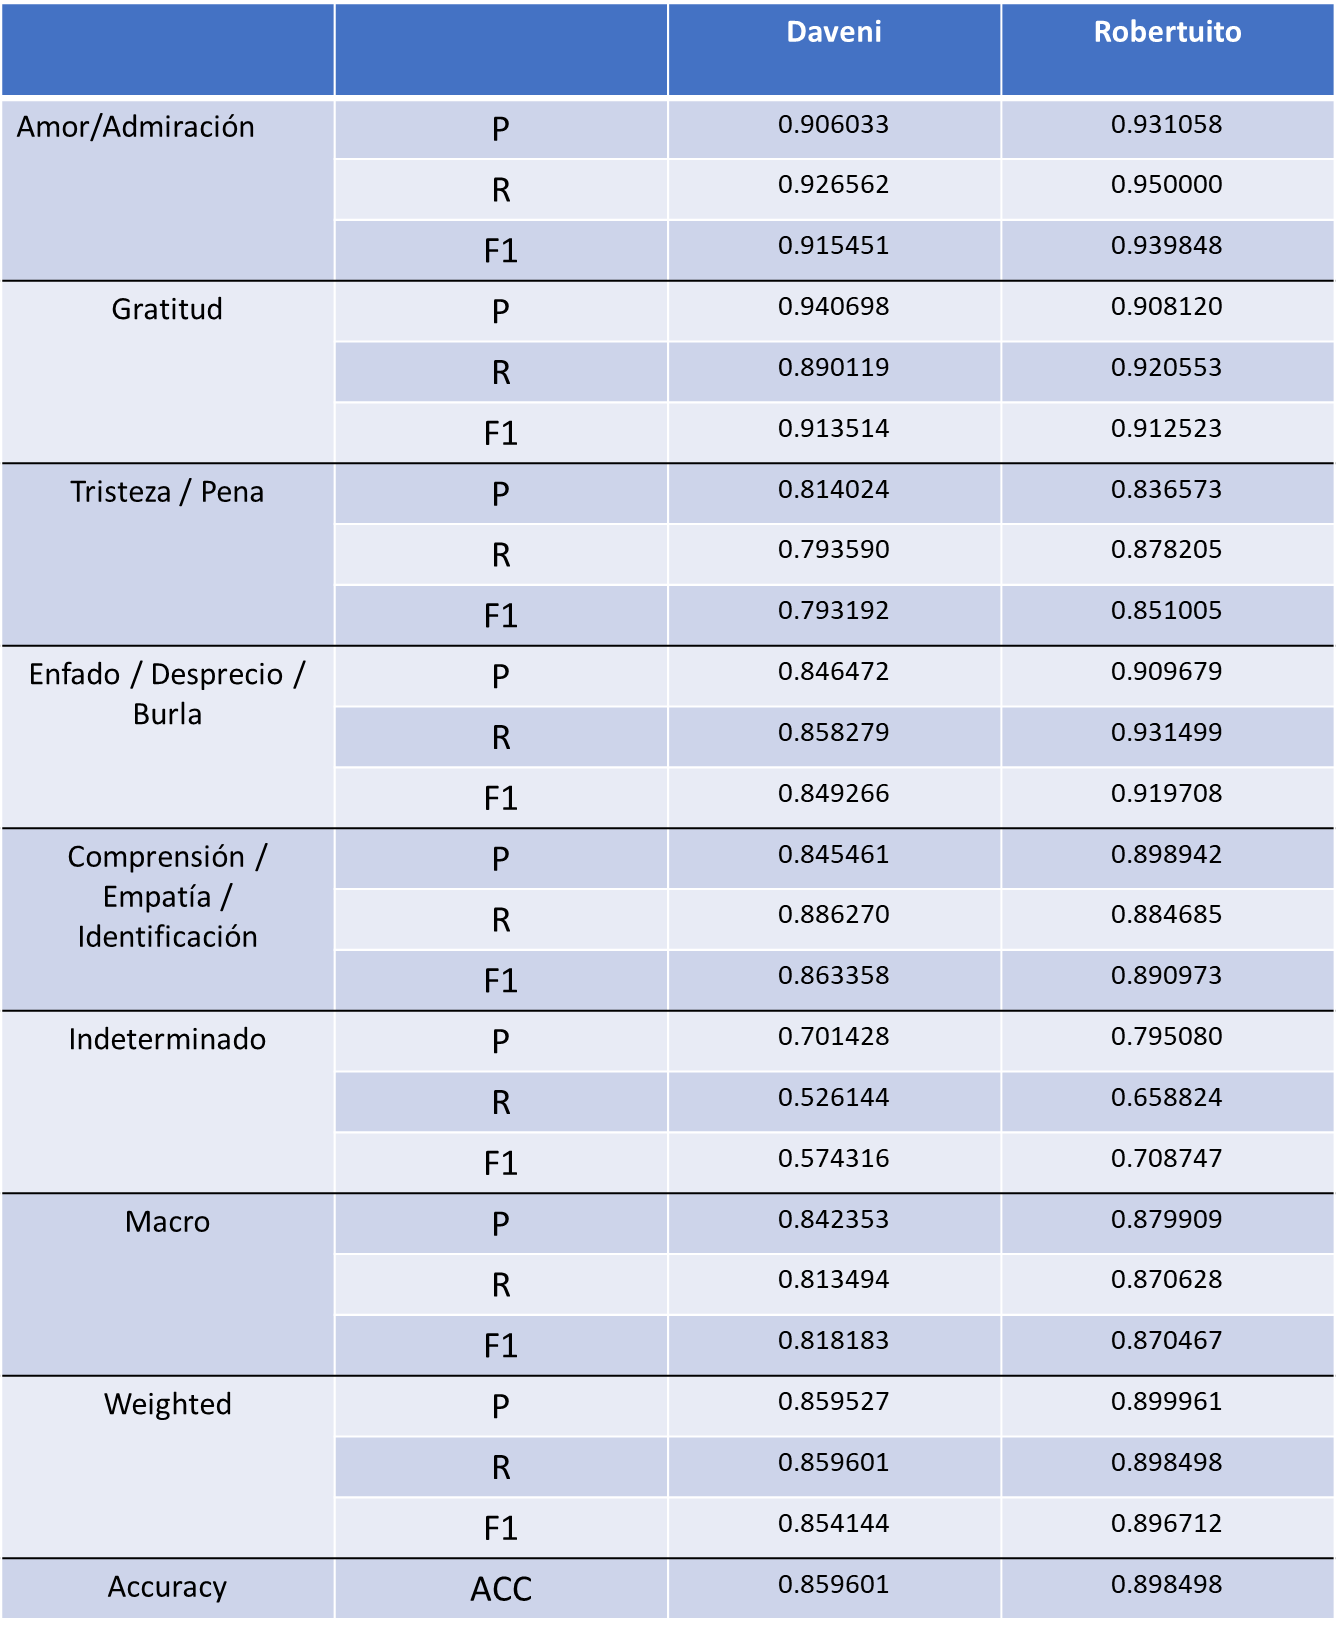

### **Confusion Matrix**

In [ ]:
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}


model = AutoModelForSequenceClassification.from_pretrained("daveni/twitter-xlm-roberta-emotion-es", num_labels=6, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
tokenizer = AutoTokenizer.from_pretrained("daveni/twitter-xlm-roberta-emotion-es")
data_collator = DataCollatorWithPadding(tokenizer)


dataset = load_corpus_Salud(drop=0, n_labels=6, task="emotion")
train, test = train_test_split(dataset, stratify=dataset["label"], random_state=10)
train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

training_args = TrainingArguments(learning_rate=0.00001409, num_train_epochs=12, per_device_train_batch_size = 8, per_device_eval_batch_size=2,
                                  output_dir="best-sweep-2", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[earlyStop]
)
trainer.train()
pred=trainer.predict(tokenized_datasets["test"])
logits=pred.predictions
prob=tf.nn.softmax(logits)
res=np.argmax(prob, axis=1) #predicciones

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at daveni/twitter-xlm-roberta-emotion-es and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-d7cea5b65395ee0d/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1. Subsequent calls will reuse this data.


...

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


<IPython.core.display.Javascript object>

wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.569525,0.809441,0.755448,0.809441,0.778058
2,No log,0.478654,0.854895,0.852263,0.854895,0.852973
3,0.619800,0.577765,0.868881,0.867006,0.868881,0.866720
4,0.619800,0.724440,0.844406,0.846625,0.844406,0.843875


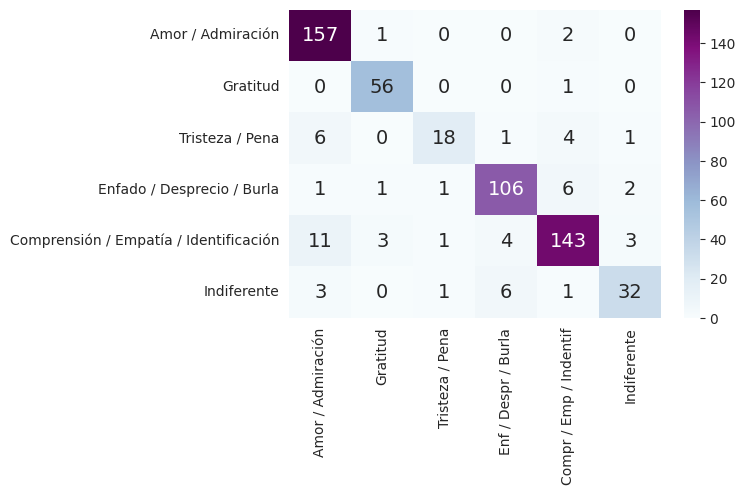

In [ ]:
matriz_confusion = confusion_matrix(tokenized_datasets["test"]["label"], res)

df_matriz_confusion = pd.DataFrame(matriz_confusion,
                                   index = ['Amor / Admiración', 'Gratitud', 'Tristeza / Pena', 'Enfado / Desprecio / Burla', 'Comprensión / Empatía / Identificación', 'Indiferente'],
                                    columns = ['Amor / Admiración', 'Gratitud', 'Tristeza / Pena', 'Enf / Despr / Burla', 'Compr / Emp / Indentif', 'Indiferente'])

plt.figure(figsize = (6, 4))
sns.heatmap(df_matriz_confusion, annot = True,fmt='g', annot_kws={"size": 14}, cmap = 'BuPu');

In [ ]:
id2label = {0: "joy", 1: "fear", 2: "sadness", 3:"anger", 4:"surprise", 5:"others"}
label2id = {"joy": 0, "fear": 1, "sadness": 2, "anger":3, "surprise":4, "others":5}


#"daveni/twitter-xlm-roberta-emotion-es"
#"pysentimiento/robertuito-emotion-analysis"
model = AutoModelForSequenceClassification.from_pretrained("pysentimiento/robertuito-emotion-analysis", num_labels=6, id2label=id2label, label2id=label2id, ignore_mismatched_sizes=True)
tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-emotion-analysis")
data_collator = DataCollatorWithPadding(tokenizer)


dataset = load_corpus_Salud(drop=0, n_labels=6, task="emotion")
train, test = train_test_split(dataset, stratify=dataset["label"], random_state=10)
train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)

training_args = TrainingArguments(learning_rate=0.00007557, num_train_epochs=6, per_device_train_batch_size = 16, per_device_eval_batch_size=16,
                                  output_dir="best-sweep-", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    compute_metrics=compute_metrics,
    tokenizer=tokenizer,
    data_collator=data_collator,
    callbacks=[earlyStop]
)
trainer.train()
pred=trainer.predict(tokenized_datasets["test"])
logits=pred.predictions
prob=tf.nn.softmax(logits)
res=np.argmax(prob, axis=1) #predicciones

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at pysentimiento/robertuito-emotion-analysis and are newly initialized because the shapes did not match:
- classifier.out_proj.weight: found shape torch.Size([7, 768]) in the checkpoint and torch.Size([6, 768]) in the model instantiated
- classifier.out_proj.bias: found shape torch.Size([7]) in the checkpoint and torch.Size([6]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-c2f6cd623c177fef/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1. Subsequent calls will reuse this data.


  0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/1714 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a PreTrainedTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.352679,0.875874,0.876758,0.875874,0.874929
2,No log,0.439332,0.891608,0.893100,0.891608,0.889830
3,No log,0.528281,0.884615,0.884244,0.884615,0.883668


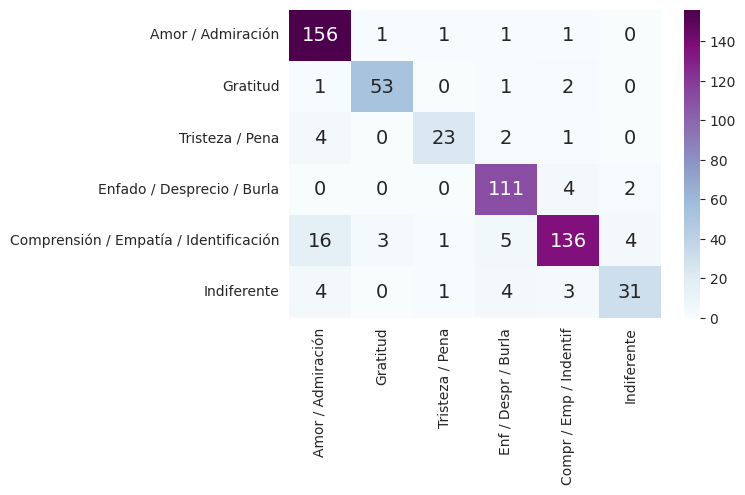

In [ ]:
matriz_confusion = confusion_matrix(tokenized_datasets["test"]["label"], res)

df_matriz_confusion = pd.DataFrame(matriz_confusion,
                                   index = ['Amor / Admiración', 'Gratitud', 'Tristeza / Pena', 'Enfado / Desprecio / Burla', 'Comprensión / Empatía / Identificación', 'Indiferente'],
                                    columns = ['Amor / Admiración', 'Gratitud', 'Tristeza / Pena', 'Enf / Despr / Burla', 'Compr / Emp / Indentif', 'Indiferente'])

plt.figure(figsize = (6, 4))
sns.heatmap(df_matriz_confusion, annot = True,fmt='g', annot_kws={"size": 14}, cmap = 'BuPu');

# **Example of predicting emotions of a text using the trained models**

In [ ]:
predict(name="robertuito", task="emotion",
        data=["te quiero", "te odio", "me das pena", "no tengo una opinion clara al respecto",
              "siento profundamente tu reciente pérdida",
              "soy vegano porque siento que debo hacer algo por el bienestar animal"])

['Amor/Admiración',
 'Enfado/Desprecio/Burla',
 'Enfado/Desprecio/Burla',
 'Enfado/Desprecio/Burla',
 'Tristeza/Pena',
 'Comprensión/Empatía/Identificación']

# **Save models**

In [ ]:
dataset = load_corpus_Salud(0, n_labels=2, task="sentiment")
id2label = {0: "NEG",  1: "POS"}
label2id = {"NEG": 0, "POS": 1}


tokenizer = AutoTokenizer.from_pretrained('pysentimiento/roberta-es-sentiment')
model = AutoModelForSequenceClassification.from_pretrained('pysentimiento/roberta-es-sentiment', num_labels=3, label2id = label2id, id2label=id2label, ignore_mismatched_sizes=True)
data_collator = DataCollatorWithPadding(tokenizer)

train, test = train_test_split(dataset, stratify=dataset["label"])

train.to_csv("corpus_train.csv", index=False)
test.to_csv("corpus_test.csv", index=False)
train_test = load_dataset("csv", data_files={"train":"./corpus_train.csv", "test":"./corpus_test.csv"})
tokenized_datasets = train_test.map(tokenize_function, batched=True)


training_args = TrainingArguments(learning_rate=0.00004863, num_train_epochs=13, per_device_train_batch_size = 64, per_device_eval_batch_size=128,
                                  output_dir="best-sweep-", evaluation_strategy="epoch", fp16=True, save_strategy="epoch", load_best_model_at_end = True, metric_for_best_model="accuracy") #necesario para earlyStop
trainer = Trainer(
      model=model,
      args=training_args,
      train_dataset=tokenized_datasets["train"],
      eval_dataset=tokenized_datasets["test"],
      compute_metrics=compute_metrics,
      data_collator=data_collator,
      callbacks=[earlyStop]
)
trainer.train()

model.save_pretrained("./model_roberta_sentiment")
tokenizer.save_pretrained("./tok_roberta_sentiment")

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

Dataset csv downloaded and prepared to /root/.cache/huggingface/datasets/csv/default-7015201c6c496f6a/0.0.0/6954658bab30a358235fa864b05cf819af0e179325c740e4bc853bcc7ec513e1. Subsequent calls will reuse this data.


  0%|          | 0/2 [00:00<?, ?it/s]

Map:   0%|          | 0/1714 [00:00<?, ? examples/s]

Map:   0%|          | 0/572 [00:00<?, ? examples/s]

/usr/local/lib/python3.10/dist-packages/transformers/optimization.py:391: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
You're using a RobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.336776,0.872378,0.868615,0.872378,0.866177
2,No log,0.318856,0.902098,0.896229,0.902098,0.894954
3,No log,0.432766,0.891608,0.900299,0.891608,0.894824


TrainOutput(global_step=81, training_loss=0.20138220139491705, metrics={'train_runtime': 67.3215, 'train_samples_per_second': 330.979, 'train_steps_per_second': 5.214, 'total_flos': 338232298489344.0, 'train_loss': 0.20138220139491705, 'epoch': 3.0})